# Resource estimates: gate counts of one Trotter step of $\hat H\otimes\hat p$

Companion notebook to Sec. V of *"Tensor-network benchmarking of quantum phase estimation in the von Neumann
measurement formulation with DMRG-prepared initial states"* (Y. Javanmard). It reproduces Table III (counting model) and
Table IV (compiled circuits) for the systems of the paper:

| System | qubits (system + pointer) | Pauli terms $K$ |
|---|---|---|
| Heisenberg model, $4\times3$ triangular lattice, periodic | 12 + 4 | 108 |
| $\mathrm{H}_8$, STO-3G, $\mathbb Z_2$-tapered | 13 + 4 | 2912 |
| pyridine, STO-3G, (8e,8o), $\mathbb Z_2$-tapered | 13 + 4 | 2764 |

One first-order Trotter step of $e^{-it\hat H\otimes\hat p}$ with $\hat p=\sum_{j=1}^r 2^{-j}(1-\hat Z_j)/2$ is the
product over Pauli terms $c_i\hat h_i$ of the rotation of $\hat h_i$ and of the rotations of $\hat h_i\hat Z_j$,
$j=1,\dots,r$, i.e. $(r+1)K$ Pauli rotations ($r=4$, $\delta t=0.05$).

Strategies (`scripts/compile_resources.py`):

* **model**: counting model of the paper, a CNOT ladder of $2(w-1)$ CNOTs per system string of weight $w$, plus
  $G_{\rm ctrl}rK$ with $G_{\rm ctrl}=2$ for the pointer coupling;
* **qiskit**: Qiskit transpiler, optimization level 3, basis {cx, rz, sx, x};
* **rustiq**: the same, with the Rustiq synthesis of Pauli-rotation sequences (built into Qiskit >= 1.3);
* **tket**: pytket, `GreedyPauliSimp` + `FullPeepholeOptimise`.

Every compiled circuit is checked against the exact product of Pauli rotations on a random state
(`infidelity` column). Compilers drop rotations with very small angles; with `ANGLE_SCALE=1000` all angles are
of order one, which separates the structural reduction from this approximation.

**Environment.** `pip install -r requirements-compile.txt` (qiskit >= 2.5, pytket, pytket-qiskit). The Heisenberg
cells run in under a minute; the molecular compilations take 1-10 min each and are switched off by default
(`RUN_MOLECULES`), in which case the stored results in `results/compile_resources.jsonl` are used.

In [1]:
import os, sys, json, time
import numpy as np
import matplotlib.pyplot as plt
REPO = os.path.abspath(os.path.join(os.getcwd(), ".."))
sys.path.insert(0, os.path.join(REPO, "scripts"))
import compile_resources as C
import qiskit, pytket
print("qiskit", qiskit.__version__, "| pytket", pytket.__version__)
RUN_MOLECULES = False          # True: recompile H8 and pyridine (about 30 min in total)
JSONL = os.path.join(REPO, "results", "compile_resources.jsonl")

qiskit 2.5.2 | pytket 2.18.4


## 1. Hamiltonians

The Heisenberg Hamiltonian is generated on the fly (36 bonds of the periodic $4\times3$ triangular lattice, $J=1$).
The tapered molecular Hamiltonians are read from `data/tapered_hamiltonians.json`, written by
`scripts/export_tapered.py` (Tangelo, Jordan-Wigner, $\mathbb Z_2$ tapering 16 -> 13 qubits).

In [2]:
tapered = json.load(open(os.path.join(REPO, "data", "tapered_hamiltonians.json")))
HAMS = {"heisenberg": C.heisenberg_triangular_4x3(),
        "H8_tapered": (tapered["H8"]["terms"], tapered["H8"]["n"]),
        "pyridine_tapered": (tapered["pyridine"]["terms"], tapered["pyridine"]["n"])}
for name, (H, n) in HAMS.items():
    K = sum(set(s) != {"I"} for s in H)
    w = [sum(a != "I" for a in s) for s in H if set(s) != {"I"}]
    print(f"{name:17s} qubits={n:2d}  K={K:5d}  max weight={max(w):2d}  mean weight={np.mean(w):.1f}")

heisenberg        qubits=12  K=  108  max weight= 2  mean weight=2.0
H8_tapered        qubits=13  K= 2912  max weight=13  mean weight=7.4
pyridine_tapered  qubits=13  K= 2764  max weight=13  mean weight=6.5


## 2. Counting model (Table III)

$G^{\rm sim}_{\rm step}=\sum_i 2(w_i-1)$ and $G_{\rm ctrl}rK=2rK$.

In [3]:
MODEL = {}
for name, (H, n) in HAMS.items():
    sim = C.baseline(*C.rotations(H, n, pointer=False))["cx"]
    tot = C.baseline(*C.rotations(H, n, pointer=True), pointer=True)["cx"]
    MODEL[name] = tot
    print(f"{name:17s} G_sim = {sim:6d}   G_ctrl r K = {tot - sim:6d}   total per step = {tot:6d}")

heisenberg        G_sim =    216   G_ctrl r K =    864   total per step =   1080
H8_tapered        G_sim =  37500   G_ctrl r K =  23296   total per step =  60796
pyridine_tapered  G_sim =  30444   G_ctrl r K =  22112   total per step =  52556


## 3. Compiling one Trotter step: Heisenberg model

All three compilers, with the verification against the exact product of Pauli rotations.

In [4]:
def compile_once(name, strategy, angle_scale=1.0):
    H, n = HAMS[name]
    C.ANGLE_SCALE = angle_scale
    rots, nq = C.rotations(H, n, pointer=True)
    t0 = time.time()
    if strategy == "qiskit":
        res = C.qiskit_opt(rots, nq)
    elif strategy == "rustiq":
        res = C.qiskit_opt(rots, nq, plugin="rustiq")
    elif strategy == "tket":
        res = C.tket(rots, nq)
    elif strategy == "routed_line":
        from qiskit.transpiler import CouplingMap
        res = C.qiskit_opt(rots, nq, plugin="rustiq", coupling=CouplingMap.from_line(nq))
    C.ANGLE_SCALE = 1.0
    return dict(system=name, pointer=True, strategy=strategy, angle_scale=angle_scale, qubits=nq,
                seconds=round(time.time() - t0, 1), **res)

live = []
for strategy in ("qiskit", "rustiq", "tket"):
    rec = compile_once("heisenberg", strategy)
    live.append(rec)
    print(f"{strategy:12s} CNOT = {rec['cx']:5d}  2q-depth = {rec['depth']:5d}  "
          f"infidelity = {rec.get('infidelity', float('nan')):.1e}  ({rec['seconds']} s)")
print("model:", MODEL["heisenberg"])

qiskit       CNOT =  1944  2q-depth =  1793  infidelity = 4.8e-14  (2.0 s)


rustiq       CNOT =  1008  2q-depth =   936  infidelity = 3.3e-14  (1.1 s)


tket         CNOT =   866  2q-depth =   526  infidelity = 7.2e-14  (13.2 s)
model: 1080


## 4. Molecules

With `RUN_MOLECULES = True` the molecular Trotter steps are recompiled here (TKET takes about 10 min per
molecule), with real angles and with `ANGLE_SCALE = 1000`. Otherwise the stored, verified results are loaded.

In [5]:
if RUN_MOLECULES:
    for name in ("H8_tapered", "pyridine_tapered"):
        for strategy in ("qiskit", "rustiq", "tket"):
            for scale in (1.0, 1000.0):
                rec = compile_once(name, strategy, scale)
                live.append(rec)
                print(f"{name:17s} {strategy:12s} scale={scale:6.0f}  CNOT = {rec['cx']:6d}  "
                      f"infidelity = {rec.get('infidelity', float('nan')):.1e}  ({rec['seconds']} s)")
stored = [json.loads(l) for l in open(JSONL)]
records = stored + live
print(len(stored), "stored records,", len(live), "computed in this session")

24 stored records, 3 computed in this session


## 5. Table IV

For each system and strategy, the circuit of $\hat H\otimes\hat p$ with real angles; for Rustiq and Qiskit on the
molecules the structural count (`ANGLE_SCALE = 1000`) is shown in parentheses when the real-angle circuit is
approximate (infidelity $>10^{-9}$, marked `*`).

In [6]:
def pick(name, strategy, scale):
    rs = [r for r in records if r["system"] == name and r["strategy"] == strategy and r["pointer"]
          and r.get("angle_scale", 1.0) == scale and r.get("screen", 0.0) == 0.0]
    return rs[-1] if rs else None

def cell(name, strategy):
    r = pick(name, strategy, 1.0)
    if r is None:
        return "-"
    s = f"{r['cx']:,}"
    if r.get("infidelity", 0.0) > 1e-9:
        r2 = pick(name, strategy, 1000.0)
        s += "*" + (f" ({r2['cx']:,})" if r2 and r2["cx"] != r["cx"] else "")
    return s

labels = {"heisenberg": "Heisenberg 4x3 (16, 108)", "H8_tapered": "H8 (17, 2912)", "pyridine_tapered": "pyridine (17, 2764)"}
head = ["system (qubits, K)", "model", "Qiskit O3", "Rustiq", "TKET"]
rows = [[labels[n], f"{MODEL[n]:,}"] + [cell(n, s) for s in ("qiskit", "rustiq", "tket")] for n in HAMS]
wid = [max(len(x) for x in col) for col in zip(head, *rows)]
for r in [head, ["-" * w for w in wid]] + rows:
    print("  ".join(x.ljust(w) for x, w in zip(r, wid)))

system (qubits, K)        model   Qiskit O3  Rustiq            TKET            
------------------------  ------  ---------  ----------------  ----------------
Heisenberg 4x3 (16, 108)  1,080   1,944      1,008             866             
H8 (17, 2912)             60,796  90,063*    25,413* (44,160)  25,158          
pyridine (17, 2764)       52,556  16,184*    5,838* (25,614)   23,723* (24,083)


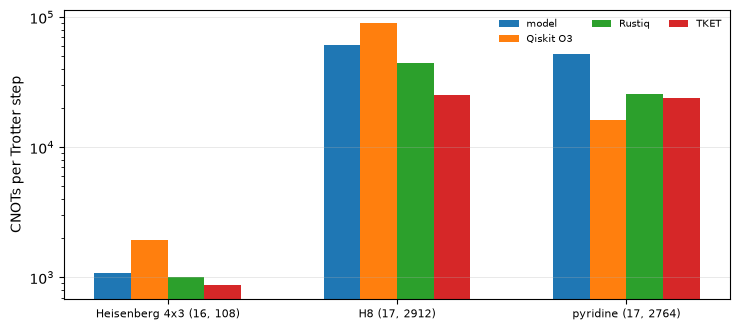

In [7]:
fig, ax = plt.subplots(figsize=(7.5, 3.4))
strategies = [("model", None), ("Qiskit O3", "qiskit"), ("Rustiq", "rustiq"), ("TKET", "tket")]
x = np.arange(len(HAMS)); w = 0.16
for k, (lab, s) in enumerate(strategies):
    vals = []
    for n in HAMS:
        if s is None:
            vals.append(MODEL[n]); continue
        r = pick(n, s, 1.0)
        if r and r.get("infidelity", 0.0) > 1e-9 and pick(n, s, 1000.0):
            r = pick(n, s, 1000.0)                      # structural count
        vals.append(r["cx"] if r else np.nan)
    ax.bar(x + (k - 1.5) * w, vals, width=w, label=lab)
ax.set_xticks(x); ax.set_xticklabels([labels[n] for n in HAMS], fontsize=8)
ax.set_yscale("log"); ax.set_ylabel("CNOTs per Trotter step")
ax.legend(fontsize=7, ncol=3, frameon=False); ax.grid(axis="y", lw=0.4, alpha=0.5)
plt.tight_layout(); plt.show()

## 6. Cost of a full circuit and of the pointer QFT

Total two-qubit gate count of one circuit execution up to $t=n\,\delta t$ (paper Eq. 45, without state
preparation and routing): $G_{\rm tot}\approx n\,G_{\rm step}+G_{\rm QFT}(r)$. For the pointer QFT, Parity Twine
networks give a SWAP-free implementation on a linear nearest-neighbour chain with $r^2-1$ CNOTs and depth $5r-3$
(Klaver et al., Phys. Rev. A 113, 012443 (2026), arXiv:2408.10907; see also Kazemi et al., arXiv:2609.03583).

In [8]:
n_steps = int(round(25 / 0.05))            # H8 reaches chemical accuracy at t = 25 / Ha
for lab, G in (("model", MODEL["H8_tapered"]), ("TKET", pick("H8_tapered", "tket", 1.0)["cx"])):
    print(f"H8, {lab:5s}: {n_steps} steps x {G:,} = {n_steps * G:.2e} CNOTs")
for r in (4, 6, 8, 10):
    print(f"pointer QFT, r = {r:2d}: Parity Twine (1D chain, no SWAPs) {r*r - 1:3d} CNOTs, depth {5*r - 3:2d};"
          f"  all-to-all textbook QFT {r*(r-1)//2:2d} controlled phases = {r*(r-1):3d} CNOTs")

H8, model: 500 steps x 60,796 = 3.04e+07 CNOTs
H8, TKET : 500 steps x 25,158 = 1.26e+07 CNOTs
pointer QFT, r =  4: Parity Twine (1D chain, no SWAPs)  15 CNOTs, depth 17;  all-to-all textbook QFT  6 controlled phases =  12 CNOTs
pointer QFT, r =  6: Parity Twine (1D chain, no SWAPs)  35 CNOTs, depth 27;  all-to-all textbook QFT 15 controlled phases =  30 CNOTs
pointer QFT, r =  8: Parity Twine (1D chain, no SWAPs)  63 CNOTs, depth 37;  all-to-all textbook QFT 28 controlled phases =  56 CNOTs
pointer QFT, r = 10: Parity Twine (1D chain, no SWAPs)  99 CNOTs, depth 47;  all-to-all textbook QFT 45 controlled phases =  90 CNOTs
